In [1]:
import gzip
import pandas as pd
from collections import defaultdict

ibd_path = "lwk.refined_ibd.merged.ibd.gz"

In [2]:
total_autosomal_bp = 2_800_000_000  # ~2.8 Gb from 1 to 22

In [3]:
def canonical_pair(iid1, iid2):
    return (iid1, iid2) if iid1 <= iid2 else (iid2, iid1)

def read_refined_ibd_segments(ibd_path, chrom_min=1, chrom_max=22, min_lod=None, min_bp=None):
    """
    Reads Refined IBD / merged-ibd-segments output.
    Returns a list of dict rows with canonical (A,B), chrom, start, end, lod.
    """
    rows = []
    with gzip.open(ibd_path, "rt") as f:
        for line in f:
            if not line.strip():
                continue
            parts = line.split()

            # Common column pattern:
            # id1 h1 id2 h2 chrom start end lod [extra...]
            if len(parts) < 8:
                continue

            id1, h1, id2, h2, chrom, start, end, lod = parts[:8]
            chrom = int(chrom)
            if chrom < chrom_min or chrom > chrom_max:
                continue

            iid1 = id1.split("_")[0]
            iid2 = id2.split("_")[0]
            A, B = canonical_pair(iid1, iid2)

            s = int(start); e = int(end)
            if e < s:
                s, e = e, s

            lod = float(lod)
            if (min_lod is not None) and (lod < min_lod):
                continue
                
            if (min_bp is not None) and ((e - s + 1) < min_bp):
                continue

            rows.append({"A": A, "B": B, "chrom": chrom, "start": s, "end": e, "lod": lod})
    return rows

def merge_intervals(intervals):
    """Merge overlapping/adjacent intervals. intervals: list[(s,e)]"""
    if not intervals:
        return []
    intervals = sorted(intervals)
    merged = [list(intervals[0])]
    for s, e in intervals[1:]:
        if s <= merged[-1][1] + 1:
            merged[-1][1] = max(merged[-1][1], e)
        else:
            merged.append([s, e])
    return [(s, e) for s, e in merged]

In [4]:
def summarize_pairs(segments, total_autosomal_bp):
    # Collect raw lengths + per-pair per-chrom intervals for union coverage
    pair_chrom_intervals = defaultdict(lambda: defaultdict(list))
    pair_raw_lens = defaultdict(list)
    pair_lods = defaultdict(list)
    total_autosomal_mb = total_autosomal_bp / 1e6

    for r in segments:
        A, B = r["A"], r["B"]
        seg_len = r["end"] - r["start"] + 1
        pair_raw_lens[(A, B)].append(seg_len)
        pair_lods[(A, B)].append(r["lod"])

    rows = []
    for (A, B), lens in pair_raw_lens.items():
        total_bp_merged = sum(lens)   # already merged upstream
        total_mb_merged = total_bp_merged / 1e6
        coverage = total_mb_merged / total_autosomal_mb

        rows.append({
            "A": A,
            "B": B,
            "nseg_raw": len(lens),
            "total_mb_merged": total_mb_merged,
            "mean_seg_mb_raw": (total_bp_merged / len(lens)) / 1e6 if lens else 0.0,
            "max_seg_mb_raw": (max(lens) / 1e6) if lens else 0.0,
            "mean_lod": sum(pair_lods[(A, B)]) / len(pair_lods[(A, B)]),
            "max_lod": max(pair_lods[(A, B)]),
            "coverage": coverage,
        })

    df = pd.DataFrame(rows)
    df = df.sort_values(["coverage", "nseg_raw"], ascending=False).reset_index(drop=True)
    return df

In [5]:
segs = read_refined_ibd_segments(ibd_path, min_lod=None, min_bp=None)
pair_stats = summarize_pairs(segs, total_autosomal_bp)

# top relatives (30)
pair_stats.head(30)

,A,B,nseg_raw,total_mb_merged,mean_seg_mb_raw,max_seg_mb_raw,mean_lod,max_lod,coverage
0,NA19396,NA19397,257,1468.666390,5.714655,66.132712,59.485759,573.88,0.524524
1,NA19443,NA19470,265,1453.740420,5.485813,63.045315,49.076528,549.75,0.519193
2,NA19331,NA19334,231,1396.209333,6.044196,96.961685,55.658398,737.19,0.498646
3,NA19347,NA19352,243,1385.001467,5.699595,97.266672,45.662222,419.16,0.494643
4,NA19434,NA19444,243,1353.065474,5.568171,61.296844,53.472263,698.20,0.483238
5,NA19381,NA19382,414,1316.977196,3.181104,31.558513,24.790145,108.47,0.470349
6,NA19445,NA19453,426,1297.921203,3.046763,22.778724,25.052300,136.34,0.463543
7,NA19313,NA19331,419,1260.642037,3.008692,28.836875,22.977589,96.60,0.450229
8,NA19373,NA19374,201,1258.612092,6.261752,57.460843,69.206716,673.70,0.449504
9,NA19469,NA19470,418,1246.050868,2.980983,26.567734,22.888684,118.43,0.445018


plink_pc_pairs:

    ["NA19313", "NA19331"] - Row 7
    
    ["NA19381", "NA19382"] - Row 5
    
    ["NA19445", "NA19453"] - Row 6
    
    ["NA19469", "NA19470"] - Row 9

plink_sib_pairs:

    ["NA19331", "NA19334"] - Row 2, Not GT
    
    ["NA19347", "NA19352"] - Row 3
    
    ["NA19373", "NA19374"] - Row 8
    
    ["NA19396", "NA19397"] - Row 0
    
    ["NA19434", "NA19444"] - Row 4
    
    ["NA19443", "NA19470"] - Row 1

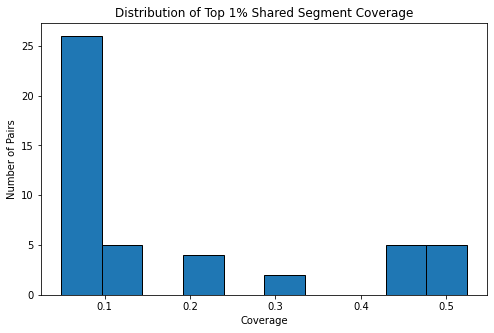

In [6]:
import matplotlib.pyplot as plt

# Plot 1: Frequency of Coverage among Top 1%
top1 = pair_stats[pair_stats["coverage"] >= pair_stats["coverage"].quantile(0.99)].copy()

plt.figure(figsize=(8,5))
plt.hist(top1["coverage"], bins=10, edgecolor="black")
plt.xlabel("Coverage")
plt.ylabel("Number of Pairs")
plt.title("Distribution of Top 1% Shared Segment Coverage")
plt.show()

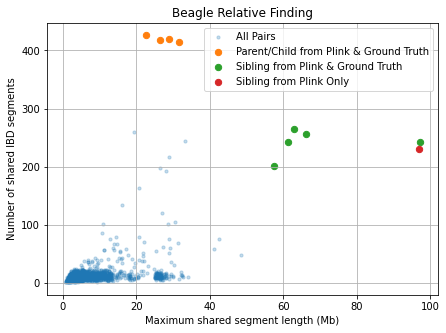

In [7]:
# Plot 2: Maximum shared segment length vs. Number of shared segments

plt.figure(figsize=(7, 5))

# all pairs
plt.scatter(
    pair_stats["max_seg_mb_raw"],
    pair_stats["nseg_raw"],
    s=10,
    alpha=0.25,
    label="All Pairs"
)

# parent/child-like
pc_rows = [5, 6, 7, 9]
pc_like = [[pair_stats["max_seg_mb_raw"][i] for i in pc_rows], [pair_stats["nseg_raw"][i] for i in pc_rows]]
plt.scatter(
    pc_like[0],
    pc_like[1],
    s=40,
    marker="o",
    label="Parent/Child from Plink & Ground Truth"
)

# Plink + GT sibling-like
sib_rows = [0, 1, 3, 4, 8]
sib_like = [pair_stats["max_seg_mb_raw"][i] for i in sib_rows], [pair_stats["nseg_raw"][i] for i in sib_rows]
plt.scatter(
    sib_like[0],
    sib_like[1],
    s=40,
    marker="o",
    label="Sibling from Plink & Ground Truth"
)

# Plink sibling-like
sib_nongt_rows = [2]
sib_nongt = [pair_stats["max_seg_mb_raw"][i] for i in sib_nongt_rows], [pair_stats["nseg_raw"][i] for i in sib_nongt_rows]
plt.scatter(
    sib_nongt[0],
    sib_nongt[1],
    s=40,
    marker="o",
    label="Sibling from Plink Only"
)

plt.xlabel("Maximum shared segment length (Mb)")
plt.ylabel("Number of shared IBD segments")
plt.title("Beagle Relative Finding")
plt.grid()
plt.legend()
plt.show()